**SECTION 6.1**

In [ ]:
# ============================================================
# SECTION 6.1 — DATA AND SIOUX FALLS NETWORK REPRESENTATION
# ============================================================

import numpy as np
import pandas as pd

NET_FILE = "/content/SiouxFalls_net.csv"
NODE_FILE = "/content/SiouxFalls_node.csv"
OD_FILE = "/content/SiouxFalls_od.csv"

print("Loading Sioux Falls data...")

links = pd.read_csv(NET_FILE)
nodes = pd.read_csv(NODE_FILE)
od = pd.read_csv(OD_FILE)

# Clean and rename
links = links.rename(columns={"A": "tail", "B": "head"})
nodes = nodes.rename(columns={"Node": "node", "X": "x", "Y": "y"})
od = od.rename(columns={"O": "origin", "D": "destination", "Ton": "demand"})

# Numeric conversion
for col in ["tail","head","a0","a4"]:
    links[col] = pd.to_numeric(links[col], errors="coerce")

od["origin"] = pd.to_numeric(od["origin"], errors="coerce")
od["destination"] = pd.to_numeric(od["destination"], errors="coerce")
od["demand"] = pd.to_numeric(od["demand"], errors="coerce")

links = links.dropna().copy()
od = od.dropna().copy()

links["tail"] = links["tail"].astype(int)
links["head"] = links["head"].astype(int)

links = links.reset_index(drop=True)
links["idx"] = np.arange(len(links))

# Pseudo-lengths
VFF_KMH = 56.3
links["t0"] = links["a0"]
links["length_km"] = VFF_KMH * links["t0"] / 60.0

print(f"Links: {len(links)}, Nodes: {len(nodes)}, OD pairs: {len(od)}")
print(f"Total OD demand: {od['demand'].sum():,.0f}")

links[["tail","head","a0","a4","length_km"]].head()

Loading Sioux Falls data...
Links: 76, Nodes: 24, OD pairs: 528
Total OD demand: 360,600


,tail,head,a0,a4,length_km
0,1,2,6,2.000000e-18,5.630000
1,1,3,4,2.000000e-18,3.753333
2,2,1,6,2.000000e-18,5.630000
3,2,6,5,1.241000e-15,4.691667
4,3,1,4,2.000000e-18,3.753333


**SECTION 6.2**

In [ ]:
# ============================================================
# SECTION 6.2
# BEHAVIORAL + TECHNOLOGICAL MODEL (TWO-CLASS ASSIGNMENT MODEL)
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# 6.2.1 REQUIRED INPUT CHECK
# ------------------------------------------------------------
required_objs = ["links", "nodes", "od"]
for obj in required_objs:
    if obj not in globals():
        raise NameError(f"Missing required object: {obj}. Run Section 6.1 first.")

links = links.copy()
nodes = nodes.copy()
od = od.copy()

# ensure fields exist
if "idx" not in links.columns:
    links = links.reset_index(drop=True)
    links["idx"] = np.arange(len(links))

if "t0_min" not in links.columns:
    links["t0_min"] = links["a0"]

if "length_km" not in links.columns:
    VFF_KMH = 56.3
    links["length_km"] = VFF_KMH * (links["t0_min"] / 60.0)
else:
    VFF_KMH = 56.3

# ------------------------------------------------------------
# 6.2.2 CORE PARAMETERS
# ------------------------------------------------------------
# units:
#   travel time      = min
#   VOT              = $/min
#   length           = km
#   op. cost         = $/km
#   emissions factor = g/km
#   mu               = $/g

# class shares in total OD demand
SHARE_PERIPH = 0.50
SHARE_CENTRAL = 0.50

# VOT by group
VOT_PERIPH = 10.0 / 60.0   # $/min
VOT_CENTRAL = 25.0 / 60.0  # $/min

# operating costs
OC_ICE = 0.17
OC_EV  = 0.085

# adoption map
G0 = -1.10
GE = 4.00
LAMBDA = 0.25

# accessibility decay (higher => more cost sensitive)
# units are 1/$ because generalized cost is in dollars
BETA_PERIPH = 0.22
BETA_CENTRAL = 0.12

# social floors as fractions of baseline accessibility
FLOOR_FRAC_PERIPH = 0.95
FLOOR_FRAC_CENTRAL = 0.95

# ------------------------------------------------------------
# 6.2.3 NETWORK FUNCTIONS
# ------------------------------------------------------------
def travel_time(flow, row):
    x = max(float(flow), 0.0)
    return (
        row["a0"]
        + row["a1"] * x
        + row["a2"] * x**2
        + row["a3"] * x**3
        + row["a4"] * x**4
    )

def pseudo_speed(flow, row):
    tt = max(travel_time(flow, row), 1e-8)
    return np.clip(VFF_KMH * row["t0_min"] / tt, 10.0, 90.0)

# tailpipe ICE emissions factor, g/km
def ef_ice(v):
    return 120.0 + 900.0 / v + 0.08 * (v - 50.0) ** 2

# per-vehicle tailpipe emissions, g/vehicle
def link_tailpipe_emission_per_vehicle(total_flow, row, s):
    v = pseudo_speed(total_flow, row)
    return row["length_km"] * (1.0 - s) * ef_ice(v)

# ------------------------------------------------------------
# 6.2.4 COSTS BY USER CLASS
# ------------------------------------------------------------
def cost_periph_ice(total_flow, row):
    return VOT_PERIPH * travel_time(total_flow, row) + row["length_km"] * OC_ICE

def cost_periph_ev(total_flow, row):
    return VOT_PERIPH * travel_time(total_flow, row) + row["length_km"] * OC_EV

def cost_central_ice(total_flow, row):
    return VOT_CENTRAL * travel_time(total_flow, row) + row["length_km"] * OC_ICE

def cost_central_ev(total_flow, row):
    return VOT_CENTRAL * travel_time(total_flow, row) + row["length_km"] * OC_EV

# weighted-average route cost entering the structural map
def average_generalized_cost(total_flow, row, s):
    return (
        (1.0 - s) * (
            SHARE_PERIPH * cost_periph_ice(total_flow, row)
            + SHARE_CENTRAL * cost_central_ice(total_flow, row)
        )
        + s * (
            SHARE_PERIPH * cost_periph_ev(total_flow, row)
            + SHARE_CENTRAL * cost_central_ev(total_flow, row)
        )
    )

# ------------------------------------------------------------
# 6.2.5 TOTAL EMISSIONS
# ------------------------------------------------------------
def total_emissions(x_periph, x_central, s):
    xtot = np.asarray(x_periph) + np.asarray(x_central)
    total = 0.0
    for _, r in links.iterrows():
        i = int(r["idx"])
        total += xtot[i] * link_tailpipe_emission_per_vehicle(xtot[i], r, s)
    return float(total)

# ------------------------------------------------------------
# 6.2.6 OD SPLIT BY USER CLASS
# ------------------------------------------------------------
od_two_class = od.copy()
od_two_class["demand_periph"] = SHARE_PERIPH * od_two_class["demand"]
od_two_class["demand_central"] = SHARE_CENTRAL * od_two_class["demand"]

# destination opportunity weights for accessibility
dest_weight = od.groupby("destination")["demand"].sum().to_dict()
dest_weight = {int(k): float(v) for k, v in dest_weight.items() if float(v) > 0}

# ------------------------------------------------------------
# 6.2.7 STRUCTURAL MAP
# ------------------------------------------------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def target_s(E, E_BAR, E0):
    return sigmoid(G0 + GE * (E - E_BAR) / E0)

def H_of_s(s, E, E_BAR, E0):
    return target_s(E, E_BAR, E0) - s

# ------------------------------------------------------------
# 6.2.8 PARAMETER TABLE
# ------------------------------------------------------------
param_df = pd.DataFrame([
    ["VFF_KMH", "Benchmark free-flow speed (km/h)", VFF_KMH],
    ["VOT_PERIPH", "Peripheral/low-income value of time ($/min)", VOT_PERIPH],
    ["VOT_CENTRAL", "Central/high-income value of time ($/min)", VOT_CENTRAL],
    ["OC_ICE", "ICE operating cost ($/km)", OC_ICE],
    ["OC_EV", "EV operating cost ($/km)", OC_EV],
    ["G0", "Adoption intercept", G0],
    ["GE", "Emissions sensitivity", GE],
    ["LAMBDA", "Partial-adjustment rate", LAMBDA],
    ["BETA_PERIPH", "Peripheral accessibility decay (1/$)", BETA_PERIPH],
    ["BETA_CENTRAL", "Central accessibility decay (1/$)", BETA_CENTRAL],
    ["FLOOR_FRAC_PERIPH", "Peripheral accessibility floor fraction", FLOOR_FRAC_PERIPH],
    ["FLOOR_FRAC_CENTRAL", "Central accessibility floor fraction", FLOOR_FRAC_CENTRAL],
], columns=["parameter", "description", "value"])

print("Two-class behavioral model initialized.")
display(param_df)

param_df.to_csv("/content/sioux_falls_parameters_revised.csv", index=False)
print("\nSaved:")
print("/content/sioux_falls_parameters_revised.csv")

Two-class behavioral model initialized.


,parameter,description,value
0,VFF_KMH,Benchmark free-flow speed (km/h),56.300000
1,VOT_PERIPH,Peripheral/low-income value of time ($/min),0.166667
2,VOT_CENTRAL,Central/high-income value of time ($/min),0.416667
3,OC_ICE,ICE operating cost ($/km),0.170000
4,OC_EV,EV operating cost ($/km),0.085000
5,G0,Adoption intercept,-1.100000
6,GE,Emissions sensitivity,4.000000
7,LAMBDA,Partial-adjustment rate,0.250000
8,BETA_PERIPH,Peripheral accessibility decay (1/$),0.220000
9,BETA_CENTRAL,Central accessibility decay (1/$),0.120000



Saved:
/content/sioux_falls_parameters_revised.csv


**SECTION 6.3**

In [ ]:
# ============================================================
# SECTION 6.3
# JOINT FLOW-STRUCTURE EQUILIBRIUM (TWO-CLASS UE + ROOT FINDING)
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
from scipy.optimize import brentq

# ------------------------------------------------------------
# 6.3.1 HELPERS
# ------------------------------------------------------------
def build_graph_class(total_flow_vec, user_class, vehicle_type):
    G = nx.DiGraph()
    for _, r in links.iterrows():
        i = int(r["idx"])
        xtot = total_flow_vec[i]

        if user_class == "periph" and vehicle_type == "ICE":
            w = cost_periph_ice(xtot, r)
        elif user_class == "periph" and vehicle_type == "EV":
            w = cost_periph_ev(xtot, r)
        elif user_class == "central" and vehicle_type == "ICE":
            w = cost_central_ice(xtot, r)
        elif user_class == "central" and vehicle_type == "EV":
            w = cost_central_ev(xtot, r)
        else:
            raise ValueError("Unknown class/type combination")

        G.add_edge(int(r["tail"]), int(r["head"]), weight=float(w), idx=i)
    return G

def aon_single_demand(G, od_df, demand_col):
    y = np.zeros(len(links), dtype=float)

    for o, group in od_df.groupby("origin"):
        origin = int(o)
        if origin not in G:
            continue
        try:
            _, paths = nx.single_source_dijkstra(G, origin, weight="weight")
        except Exception:
            continue

        for _, rr in group.iterrows():
            d = int(rr["destination"])
            q = float(rr[demand_col])
            if q <= 0 or d not in paths:
                continue

            path = paths[d]
            for u, v in zip(path[:-1], path[1:]):
                y[G[u][v]["idx"]] += q

    return y

def aon_two_class(total_flow_vec, s):
    # EV share is applied identically across groups
    od_use = od_two_class.copy()

    od_use["periph_ice"] = (1.0 - s) * od_use["demand_periph"]
    od_use["periph_ev"] = s * od_use["demand_periph"]
    od_use["central_ice"] = (1.0 - s) * od_use["demand_central"]
    od_use["central_ev"] = s * od_use["demand_central"]

    G_p_i = build_graph_class(total_flow_vec, "periph", "ICE")
    G_p_e = build_graph_class(total_flow_vec, "periph", "EV")
    G_c_i = build_graph_class(total_flow_vec, "central", "ICE")
    G_c_e = build_graph_class(total_flow_vec, "central", "EV")

    y_p_i = aon_single_demand(G_p_i, od_use, "periph_ice")
    y_p_e = aon_single_demand(G_p_e, od_use, "periph_ev")
    y_c_i = aon_single_demand(G_c_i, od_use, "central_ice")
    y_c_e = aon_single_demand(G_c_e, od_use, "central_ev")

    y_periph = y_p_i + y_p_e
    y_central = y_c_i + y_c_e
    return y_periph, y_central

def relative_gap_two_class(x_periph, x_central, y_periph, y_central, s):
    xtot = x_periph + x_central

    cbar = np.zeros(len(links), dtype=float)
    for _, r in links.iterrows():
        i = int(r["idx"])
        cbar[i] = average_generalized_cost(xtot[i], r, s)

    num = np.dot(cbar, (x_periph + x_central) - (y_periph + y_central))
    den = max(np.dot(cbar, x_periph + x_central), 1e-8)
    return float(num / den)

def fw_two_class(s, x0_periph=None, x0_central=None, max_iter=150, tol=1e-4, verbose=False):
    if x0_periph is None or x0_central is None:
        z = np.zeros(len(links), dtype=float)
        x_periph, x_central = aon_two_class(z, s)
    else:
        x_periph = np.asarray(x0_periph).copy()
        x_central = np.asarray(x0_central).copy()

    gap = np.nan
    for it in range(max_iter):
        xtot = x_periph + x_central
        y_periph, y_central = aon_two_class(xtot, s)
        gap = relative_gap_two_class(x_periph, x_central, y_periph, y_central, s)

        if verbose and (it == 0 or (it + 1) % 10 == 0):
            print(f"FW iter {it+1:3d}/{max_iter} | gap = {gap:.3e}")

        if gap < tol:
            if verbose:
                print(f"Converged in {it+1} iterations with gap = {gap:.3e}")
            return x_periph, x_central, gap, it + 1

        lam = 2.0 / (it + 2.0)
        x_periph = x_periph + lam * (y_periph - x_periph)
        x_central = x_central + lam * (y_central - x_central)

    if verbose:
        print(f"Reached max_iter with gap = {gap:.3e}")
    return x_periph, x_central, gap, max_iter

# ------------------------------------------------------------
# 6.3.2 BASELINE
# ------------------------------------------------------------
print("OD table prepared for two-class equilibrium.")
print(f"OD pairs used: {len(od_two_class)}")
print(f"Total demand: {od_two_class['demand'].sum():,.0f}")

print("\nSolving baseline UE...")
x0_periph, x0_central, gap0, it0 = fw_two_class(
    s=0.0, x0_periph=None, x0_central=None, max_iter=150, tol=1e-4, verbose=True
)

E0 = total_emissions(x0_periph, x0_central, s=0.0)
E_BAR = 0.8 * E0

print(f"\nBaseline emissions E0 = {E0:,.0f}")
print(f"Ecological ceiling E_BAR = {E_BAR:,.0f}")
print(f"FW gap = {gap0:.3e}, iterations = {it0}")

# ------------------------------------------------------------
# 6.3.3 ROOT FINDING FOR s*
# ------------------------------------------------------------
_flow_cache = {}

def H_tilde(s):
    if len(_flow_cache) == 0:
        x0p = x0_periph.copy()
        x0c = x0_central.copy()
    else:
        s_near = min(_flow_cache.keys(), key=lambda z: abs(z - s))
        x0p, x0c = _flow_cache[s_near]

    xp, xc, gap_s, it_s = fw_two_class(
        s=s, x0_periph=x0p, x0_central=x0c,
        max_iter=150, tol=1e-4, verbose=False
    )
    _flow_cache[s] = (xp.copy(), xc.copy())
    E_s = total_emissions(xp, xc, s)
    return H_of_s(s, E_s, E_BAR, E0)

H0 = H_tilde(0.0)
H1 = H_tilde(1.0)

print(f"H_tilde(0) = {H0:.6f}")
print(f"H_tilde(1) = {H1:.6f}")

if H0 * H1 < 0:
    s_star, root_res = brentq(
        H_tilde, 0.0, 1.0,
        xtol=1e-6, rtol=1e-6, full_output=True
    )
    print(f"s* = {s_star:.6f}")
    print(f"Brent converged = {root_res.converged}")
    print(f"Function calls = {root_res.function_calls}")
else:
    s_star = np.nan
    root_res = None
    print("No sign change detected on [0,1].")

summary_joint = pd.DataFrame([{
    "E0": E0,
    "E_BAR": E_BAR,
    "fw_gap": gap0,
    "fw_iters": it0,
    "H0": H0,
    "H1": H1,
    "s_star": s_star,
    "brent_converged": bool(root_res.converged) if root_res is not None else False,
    "brent_function_calls": int(root_res.function_calls) if root_res is not None else np.nan
}])

summary_joint.to_csv("/content/sioux_falls_joint_equilibrium_summary.csv", index=False)
print("\nSaved:")
print("/content/sioux_falls_joint_equilibrium_summary.csv")

OD table prepared for two-class equilibrium.
OD pairs used: 528
Total demand: 360,600

Solving baseline UE...
FW iter   1/150 | gap = 8.596e-01
FW iter  10/150 | gap = 1.006e-01
FW iter  20/150 | gap = 2.417e-02
FW iter  30/150 | gap = 1.086e-02
FW iter  40/150 | gap = 6.575e-03
FW iter  50/150 | gap = 3.596e-03
FW iter  60/150 | gap = 2.940e-03
FW iter  70/150 | gap = 1.537e-03
FW iter  80/150 | gap = 9.999e-04
FW iter  90/150 | gap = 1.398e-03
FW iter 100/150 | gap = 8.205e-04
Converged in 103 iterations with gap = 1.663e-05

Baseline emissions E0 = 631,774,651
Ecological ceiling E_BAR = 505,419,721
FW gap = 1.663e-05, iterations = 103
H_tilde(0) = 0.425557
H_tilde(1) = -0.986613
s* = 0.228526
Brent converged = True
Function calls = 7

Saved:
/content/sioux_falls_joint_equilibrium_summary.csv


**SECTION 6.4**

In [ ]:
# ============================================================
# SECTION 6.4
# TECHNOLOGICAL CHANGE, ENVIRONMENTAL ADMISSIBILITY, DYNAMICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\nScanning EV share s...")

s_grid = np.linspace(0.0, 1.0, 21)
records = []

x_prev_p = x0_periph.copy()
x_prev_c = x0_central.copy()

for s in s_grid:
    xp, xc, gap_s, it_s = fw_two_class(
        s=s,
        x0_periph=x_prev_p,
        x0_central=x_prev_c,
        max_iter=150, tol=1e-4, verbose=False
    )
    x_prev_p = xp.copy()
    x_prev_c = xc.copy()

    E_s = total_emissions(xp, xc, s)
    H_s = H_of_s(s, E_s, E_BAR, E0)
    target = target_s(E_s, E_BAR, E0)

    eco_ok = bool(E_s <= E_BAR)

    records.append({
        "s": s,
        "E": E_s,
        "H": H_s,
        "target": target,
        "eco_ok": eco_ok,
        "fw_gap": gap_s,
        "fw_iters": it_s
    })

    print(f"s={s:.2f} | E={E_s:,.0f} | H={H_s:.4f} | eco_ok={eco_ok}")

tech_df = pd.DataFrame(records)

eco_cand = tech_df[tech_df["eco_ok"]].copy()
s_adm = float(eco_cand["s"].min()) if len(eco_cand) > 0 else np.nan

print(f"\nEnvironmental admissibility threshold s_adm = {s_adm}")

# ------------------------------------------------------------
# DYNAMICS
# ------------------------------------------------------------
traj = []
s_now = 0.05
x_prev_p = None
x_prev_c = None

for t in range(15):
    xp, xc, gap_t, it_t = fw_two_class(
        s=s_now,
        x0_periph=x_prev_p,
        x0_central=x_prev_c,
        max_iter=150, tol=1e-4, verbose=False
    )
    x_prev_p = xp.copy()
    x_prev_c = xc.copy()

    E_t = total_emissions(xp, xc, s_now)
    H_t = H_of_s(s_now, E_t, E_BAR, E0)
    s_next = np.clip(s_now + LAMBDA * H_t, 0.0, 1.0)

    traj.append({
        "t": t,
        "s": s_now,
        "E": E_t,
        "H": H_t,
        "s_next": s_next,
        "fw_gap": gap_t,
        "fw_iters": it_t
    })

    print(f"t={t:2d} | s={s_now:.4f} | E={E_t:,.0f} | H={H_t:.4f} | next={s_next:.4f}")
    s_now = s_next

dyn_df = pd.DataFrame(traj)

tech_df.to_csv("/content/sioux_falls_tech_scan.csv", index=False)
dyn_df.to_csv("/content/sioux_falls_tech_dynamics.csv", index=False)

print("\nSaved:")
print("/content/sioux_falls_tech_scan.csv")
print("/content/sioux_falls_tech_dynamics.csv")


Scanning EV share s...
s=0.00 | E=631,774,651 | H=0.4256 | eco_ok=False
s=0.05 | E=600,185,919 | H=0.3275 | eco_ok=False
s=0.10 | E=568,121,267 | H=0.2311 | eco_ok=False
s=0.15 | E=536,558,974 | H=0.1385 | eco_ok=False
s=0.20 | E=504,996,682 | H=0.0492 | eco_ok=True
s=0.25 | E=473,434,389 | H=-0.0363 | eco_ok=True
s=0.30 | E=441,872,097 | H=-0.1179 | eco_ok=True
s=0.35 | E=410,026,252 | H=-0.1961 | eco_ok=True
s=0.40 | E=378,743,668 | H=-0.2701 | eco_ok=True
s=0.45 | E=347,181,696 | H=-0.3411 | eco_ok=True
s=0.50 | E=315,619,723 | H=-0.4090 | eco_ok=True
s=0.55 | E=284,057,751 | H=-0.4742 | eco_ok=True
s=0.60 | E=252,495,779 | H=-0.5371 | eco_ok=True
s=0.65 | E=220,933,806 | H=-0.5979 | eco_ok=True
s=0.70 | E=189,371,834 | H=-0.6569 | eco_ok=True
s=0.75 | E=157,809,862 | H=-0.7145 | eco_ok=True
s=0.80 | E=126,247,889 | H=-0.7707 | eco_ok=True
s=0.85 | E=94,566,367 | H=-0.8259 | eco_ok=True
s=0.90 | E=63,044,245 | H=-0.8802 | eco_ok=True
s=0.95 | E=31,514,419 | H=-0.9337 | eco_ok=True


**SECTION 6.5**

In [ ]:
# ============================================================
# SECTION 6.5
# SOCIAL FLOOR UNDER TECHNOLOGICAL CHANGE
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("\nDefining accessibility groups and floors...")

# ------------------------------------------------------------
# 6.5.1 NODE GROUPS
# ------------------------------------------------------------
nodes_use = nodes.copy()
rename_map = {}
if "Node" in nodes_use.columns:
    rename_map["Node"] = "node"
if "X" in nodes_use.columns:
    rename_map["X"] = "x"
if "Y" in nodes_use.columns:
    rename_map["Y"] = "y"
nodes_use = nodes_use.rename(columns=rename_map)

nodes_use["node"] = pd.to_numeric(nodes_use["node"], errors="coerce").astype(int)
nodes_use["x"] = pd.to_numeric(nodes_use["x"], errors="coerce")
nodes_use["y"] = pd.to_numeric(nodes_use["y"], errors="coerce")

x_cent = nodes_use["x"].mean()
y_cent = nodes_use["y"].mean()

nodes_use["dist_to_centroid"] = np.sqrt(
    (nodes_use["x"] - x_cent) ** 2 + (nodes_use["y"] - y_cent) ** 2
)

q75 = nodes_use["dist_to_centroid"].quantile(0.75)
q25 = nodes_use["dist_to_centroid"].quantile(0.25)

peripheral_nodes = set(nodes_use.loc[nodes_use["dist_to_centroid"] >= q75, "node"].astype(int))
central_nodes = set(nodes_use.loc[nodes_use["dist_to_centroid"] <= q25, "node"].astype(int))

print(f"Peripheral nodes: {len(peripheral_nodes)}")
print(f"Central nodes:    {len(central_nodes)}")

# ------------------------------------------------------------
# 6.5.2 GROUP-SPECIFIC COST GRAPHS
# ------------------------------------------------------------
def build_graph_accessibility(total_flow_vec, group_name, s):
    G = nx.DiGraph()
    for _, r in links.iterrows():
        i = int(r["idx"])
        xtot = total_flow_vec[i]

        # use class-specific perceived generalized costs
        if group_name == "periph":
            # expected cost under current fleet composition
            w = (1.0 - s) * cost_periph_ice(xtot, r) + s * cost_periph_ev(xtot, r)
        elif group_name == "central":
            w = (1.0 - s) * cost_central_ice(xtot, r) + s * cost_central_ev(xtot, r)
        else:
            raise ValueError("Unknown group")

        G.add_edge(int(r["tail"]), int(r["head"]), weight=float(w), idx=i)
    return G

# ------------------------------------------------------------
# 6.5.3 GRAVITY ACCESSIBILITY
# ------------------------------------------------------------
def gravity_accessibility_from_graph(G, origins, beta):
    vals = []
    for o in origins:
        if o not in G:
            continue
        try:
            dist, _ = nx.single_source_dijkstra(G, o, weight="weight")
        except Exception:
            continue

        acc_o = 0.0
        for d, w in dest_weight.items():
            c_od = dist.get(d, np.inf)
            if np.isfinite(c_od):
                acc_o += w * np.exp(-beta * c_od)

        vals.append(acc_o)

    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def evaluate_accessibility(x_periph, x_central, s):
    xtot = np.asarray(x_periph) + np.asarray(x_central)

    G_periph = build_graph_accessibility(xtot, "periph", s)
    G_central = build_graph_accessibility(xtot, "central", s)

    A_periph = gravity_accessibility_from_graph(G_periph, peripheral_nodes, BETA_PERIPH)
    A_central = gravity_accessibility_from_graph(G_central, central_nodes, BETA_CENTRAL)

    return A_periph, A_central

# ------------------------------------------------------------
# 6.5.4 BASELINE FLOORS
# ------------------------------------------------------------
A_periph_0, A_central_0 = evaluate_accessibility(x0_periph, x0_central, s=0.0)

A_periph_bar = FLOOR_FRAC_PERIPH * A_periph_0
A_central_bar = FLOOR_FRAC_CENTRAL * A_central_0

print(f"\nBaseline A_periph(0)  = {A_periph_0:,.3f}")
print(f"Baseline A_central(0) = {A_central_0:,.3f}")
print(f"Peripheral floor      = {A_periph_bar:,.3f}")
print(f"Central floor         = {A_central_bar:,.3f}")

# ------------------------------------------------------------
# 6.5.5 SCAN OVER s
# ------------------------------------------------------------
records_social = []
x_prev_p = x0_periph.copy()
x_prev_c = x0_central.copy()

for s in s_grid:
    xp, xc, gap_s, it_s = fw_two_class(
        s=s,
        x0_periph=x_prev_p,
        x0_central=x_prev_c,
        max_iter=150, tol=1e-4, verbose=False
    )
    x_prev_p = xp.copy()
    x_prev_c = xc.copy()

    E_s = total_emissions(xp, xc, s)
    A_p, A_c = evaluate_accessibility(xp, xc, s)

    eco_ok = bool(E_s <= E_BAR)
    social_ok = bool((A_p >= A_periph_bar) and (A_c >= A_central_bar))
    joint_ok = bool(eco_ok and social_ok)

    records_social.append({
        "s": s,
        "E": E_s,
        "A_periph": A_p,
        "A_central": A_c,
        "eco_ok": eco_ok,
        "social_ok": social_ok,
        "joint_ok": joint_ok,
        "fw_gap": gap_s,
        "fw_iters": it_s
    })

social_df = pd.DataFrame(records_social)

eco_cand = social_df[social_df["eco_ok"]].copy()
joint_cand = social_df[social_df["joint_ok"]].copy()

s_eco_min = float(eco_cand["s"].min()) if len(eco_cand) > 0 else np.nan
s_joint_min = float(joint_cand["s"].min()) if len(joint_cand) > 0 else np.nan

print(f"\ns_eco_min   = {s_eco_min}")
print(f"s_joint_min = {s_joint_min}")

# at structural fixed point
if np.isfinite(s_star):
    xp_star, xc_star, gap_star, it_star = fw_two_class(
        s=s_star,
        x0_periph=x0_periph, x0_central=x0_central,
        max_iter=150, tol=1e-4, verbose=False
    )
    E_star = total_emissions(xp_star, xc_star, s_star)
    A_p_star, A_c_star = evaluate_accessibility(xp_star, xc_star, s_star)

    print(f"\nAt s* = {s_star:.6f}")
    print(f"E(s*) = {E_star:,.0f}")
    print(f"A_periph(s*)  = {A_p_star:,.3f}")
    print(f"A_central(s*) = {A_c_star:,.3f}")
else:
    E_star = np.nan
    A_p_star = np.nan
    A_c_star = np.nan

social_df.to_csv("/content/sioux_falls_social_floor_scan_revised.csv", index=False)

summary_social = pd.DataFrame([{
    "A_periph_0": A_periph_0,
    "A_central_0": A_central_0,
    "A_periph_bar": A_periph_bar,
    "A_central_bar": A_central_bar,
    "s_eco_min": s_eco_min,
    "s_joint_min": s_joint_min,
    "s_star": s_star,
    "E_s_star": E_star,
    "A_periph_s_star": A_p_star,
    "A_central_s_star": A_c_star
}])

summary_social.to_csv("/content/sioux_falls_social_floor_summary_revised.csv", index=False)

print("\nSaved:")
print("/content/sioux_falls_social_floor_scan_revised.csv")
print("/content/sioux_falls_social_floor_summary_revised.csv")


Defining accessibility groups and floors...
Peripheral nodes: 6
Central nodes:    6

Baseline A_periph(0)  = 107,346.938
Baseline A_central(0) = 129,712.967
Peripheral floor      = 101,979.591
Central floor         = 123,227.319

s_eco_min   = 0.2
s_joint_min = 0.2

At s* = 0.228526
E(s*) = 486,957,376
A_periph(s*)  = 111,631.839
A_central(s*) = 131,523.492

Saved:
/content/sioux_falls_social_floor_scan_revised.csv
/content/sioux_falls_social_floor_summary_revised.csv


**SECTION 6.6**

In [ ]:
# ============================================================
# SECTION 6.6
# PRICING WITH ECOLOGICAL CEILING AND SOCIAL FLOOR
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("\n================================================")
print("PRICING WITH ECOLOGICAL CEILING AND SOCIAL FLOOR")
print("================================================")

# ------------------------------------------------------------
# 6.6.1 FIXED STRUCTURE
# ------------------------------------------------------------
s_fixed = 0.0
print(f"Fixed EV share s = {s_fixed:.2f}")

# ------------------------------------------------------------
# 6.6.2 TOLL DEFINITIONS
# mu has units $/g
# per-vehicle toll on a link = mu * [g/vehicle] = $/vehicle
# ------------------------------------------------------------
def d_link_emission_per_vehicle_dx(total_flow, row, s, rel_step=1e-5, abs_step=1e-6):
    x = max(float(total_flow), 0.0)
    h = max(abs_step, rel_step * max(1.0, x))

    if x >= h:
        e_plus = link_tailpipe_emission_per_vehicle(x + h, row, s)
        e_minus = link_tailpipe_emission_per_vehicle(x - h, row, s)
        return (e_plus - e_minus) / (2.0 * h)
    else:
        e0 = link_tailpipe_emission_per_vehicle(x, row, s)
        e_plus = link_tailpipe_emission_per_vehicle(x + h, row, s)
        return (e_plus - e0) / h

def marginal_emissions_term(total_flow, row, s):
    e = link_tailpipe_emission_per_vehicle(total_flow, row, s)
    de_dx = d_link_emission_per_vehicle_dx(total_flow, row, s)
    return e + total_flow * de_dx

def priced_cost(group_name, vehicle_type, total_flow, row, mu, s, scheme):
    # base private cost
    if group_name == "periph" and vehicle_type == "ICE":
        base = cost_periph_ice(total_flow, row)
    elif group_name == "periph" and vehicle_type == "EV":
        base = cost_periph_ev(total_flow, row)
    elif group_name == "central" and vehicle_type == "ICE":
        base = cost_central_ice(total_flow, row)
    elif group_name == "central" and vehicle_type == "EV":
        base = cost_central_ev(total_flow, row)
    else:
        raise ValueError("Unknown group/type")

    # toll only on ICE users
    if vehicle_type == "EV":
        toll = 0.0
    else:
        if scheme == "pv":
            toll = mu * link_tailpipe_emission_per_vehicle(total_flow, row, s)
        elif scheme == "me":
            toll = mu * marginal_emissions_term(total_flow, row, s)
        else:
            raise ValueError("scheme must be 'pv' or 'me'")

    return base + toll

# ------------------------------------------------------------
# 6.6.3 GRAPH + AON UNDER PRICING
# ------------------------------------------------------------
def build_graph_priced(total_flow_vec, group_name, vehicle_type, mu, s, scheme):
    G = nx.DiGraph()
    for _, r in links.iterrows():
        i = int(r["idx"])
        xtot = total_flow_vec[i]
        w = priced_cost(group_name, vehicle_type, xtot, r, mu, s, scheme)
        G.add_edge(int(r["tail"]), int(r["head"]), weight=float(w), idx=i)
    return G

def aon_two_class_priced(total_flow_vec, s, mu, scheme):
    od_use = od_two_class.copy()

    od_use["periph_ice"] = (1.0 - s) * od_use["demand_periph"]
    od_use["periph_ev"] = s * od_use["demand_periph"]
    od_use["central_ice"] = (1.0 - s) * od_use["demand_central"]
    od_use["central_ev"] = s * od_use["demand_central"]

    G_p_i = build_graph_priced(total_flow_vec, "periph", "ICE", mu, s, scheme)
    G_p_e = build_graph_priced(total_flow_vec, "periph", "EV",  mu, s, scheme)
    G_c_i = build_graph_priced(total_flow_vec, "central", "ICE", mu, s, scheme)
    G_c_e = build_graph_priced(total_flow_vec, "central", "EV",  mu, s, scheme)

    y_p_i = aon_single_demand(G_p_i, od_use, "periph_ice")
    y_p_e = aon_single_demand(G_p_e, od_use, "periph_ev")
    y_c_i = aon_single_demand(G_c_i, od_use, "central_ice")
    y_c_e = aon_single_demand(G_c_e, od_use, "central_ev")

    return y_p_i + y_p_e, y_c_i + y_c_e

def relative_gap_two_class_priced(x_periph, x_central, y_periph, y_central, s, mu, scheme):
    xtot = x_periph + x_central
    cbar = np.zeros(len(links), dtype=float)

    for _, r in links.iterrows():
        i = int(r["idx"])

        # weighted current generalized cost across all users
        cbar[i] = (
            (1.0 - s) * (
                SHARE_PERIPH * priced_cost("periph", "ICE", xtot[i], r, mu, s, scheme)
                + SHARE_CENTRAL * priced_cost("central", "ICE", xtot[i], r, mu, s, scheme)
            )
            + s * (
                SHARE_PERIPH * priced_cost("periph", "EV", xtot[i], r, mu, s, scheme)
                + SHARE_CENTRAL * priced_cost("central", "EV", xtot[i], r, mu, s, scheme)
            )
        )

    num = np.dot(cbar, (x_periph + x_central) - (y_periph + y_central))
    den = max(np.dot(cbar, x_periph + x_central), 1e-8)
    return float(num / den)

def fw_two_class_priced(mu, scheme, s=s_fixed,
                        x0_periph=None, x0_central=None,
                        max_iter=150, tol=1e-4, verbose=False):
    if x0_periph is None or x0_central is None:
        z = np.zeros(len(links), dtype=float)
        x_periph, x_central = aon_two_class_priced(z, s, mu, scheme)
    else:
        x_periph = np.asarray(x0_periph).copy()
        x_central = np.asarray(x0_central).copy()

    gap = np.nan
    for it in range(max_iter):
        xtot = x_periph + x_central
        y_periph, y_central = aon_two_class_priced(xtot, s, mu, scheme)
        gap = relative_gap_two_class_priced(x_periph, x_central, y_periph, y_central, s, mu, scheme)

        if verbose and (it == 0 or (it + 1) % 10 == 0):
            print(f"{scheme.upper()} iter {it+1:3d}/{max_iter} | gap = {gap:.3e}")

        if gap < tol:
            return x_periph, x_central, gap, it + 1

        lam = 2.0 / (it + 2.0)
        x_periph = x_periph + lam * (y_periph - x_periph)
        x_central = x_central + lam * (y_central - x_central)

    return x_periph, x_central, gap, max_iter

# ------------------------------------------------------------
# 6.6.4 ACCESSIBILITY UNDER PRICING
# ------------------------------------------------------------
def build_graph_accessibility_priced(total_flow_vec, group_name, s, mu, scheme):
    G = nx.DiGraph()
    for _, r in links.iterrows():
        i = int(r["idx"])
        xtot = total_flow_vec[i]

        # accessibility should reflect what the group perceives
        # use expected cost over vehicle type mix at current s
        if group_name == "periph":
            w = (1.0 - s) * priced_cost("periph", "ICE", xtot, r, mu, s, scheme) \
              + s * priced_cost("periph", "EV", xtot, r, mu, s, scheme)
        elif group_name == "central":
            w = (1.0 - s) * priced_cost("central", "ICE", xtot, r, mu, s, scheme) \
              + s * priced_cost("central", "EV", xtot, r, mu, s, scheme)
        else:
            raise ValueError("Unknown group")

        G.add_edge(int(r["tail"]), int(r["head"]), weight=float(w), idx=i)
    return G

def evaluate_accessibility_priced(x_periph, x_central, s, mu, scheme):
    xtot = np.asarray(x_periph) + np.asarray(x_central)
    Gp = build_graph_accessibility_priced(xtot, "periph", s, mu, scheme)
    Gc = build_graph_accessibility_priced(xtot, "central", s, mu, scheme)

    A_p = gravity_accessibility_from_graph(Gp, peripheral_nodes, BETA_PERIPH)
    A_c = gravity_accessibility_from_graph(Gc, central_nodes, BETA_CENTRAL)
    return A_p, A_c

# ------------------------------------------------------------
# 6.6.5 REASONABLE PRICE RANGE
# ------------------------------------------------------------
# Keep mu in a range that does not imply absurd link tolls.
# Since per-vehicle link emissions are on the order of ~10^3 g,
# mu in [1e-6, 1e-2] means tolls roughly from cents to low tens of dollars.
mu_grid = np.logspace(-6, -2, 16)

records_price = []
x_prev_p_pv, x_prev_c_pv = x0_periph.copy(), x0_central.copy()
x_prev_p_me, x_prev_c_me = x0_periph.copy(), x0_central.copy()

for mu in mu_grid:
    # per-vehicle pricing
    xp_pv, xc_pv, gap_pv, it_pv = fw_two_class_priced(
        mu=mu, scheme="pv", s=s_fixed,
        x0_periph=x_prev_p_pv, x0_central=x_prev_c_pv,
        max_iter=150, tol=1e-4, verbose=False
    )
    x_prev_p_pv, x_prev_c_pv = xp_pv.copy(), xc_pv.copy()
    E_pv = total_emissions(xp_pv, xc_pv, s_fixed)
    A_p_pv, A_c_pv = evaluate_accessibility_priced(xp_pv, xc_pv, s_fixed, mu, "pv")

    # marginal-emissions pricing
    xp_me, xc_me, gap_me, it_me = fw_two_class_priced(
        mu=mu, scheme="me", s=s_fixed,
        x0_periph=x_prev_p_me, x0_central=x_prev_c_me,
        max_iter=150, tol=1e-4, verbose=False
    )
    x_prev_p_me, x_prev_c_me = xp_me.copy(), xc_me.copy()
    E_me = total_emissions(xp_me, xc_me, s_fixed)
    A_p_me, A_c_me = evaluate_accessibility_priced(xp_me, xc_me, s_fixed, mu, "me")

    records_price.append({
        "mu": mu,

        "E_pv": E_pv,
        "A_periph_pv": A_p_pv,
        "A_central_pv": A_c_pv,
        "eco_ok_pv": bool(E_pv <= E_BAR),
        "social_ok_pv": bool((A_p_pv >= A_periph_bar) and (A_c_pv >= A_central_bar)),
        "fw_gap_pv": gap_pv,
        "fw_iters_pv": it_pv,

        "E_me": E_me,
        "A_periph_me": A_p_me,
        "A_central_me": A_c_me,
        "eco_ok_me": bool(E_me <= E_BAR),
        "social_ok_me": bool((A_p_me >= A_periph_bar) and (A_c_me >= A_central_bar)),
        "fw_gap_me": gap_me,
        "fw_iters_me": it_me,
    })

    print(
        f"mu={mu:.6e} | "
        f"PV: E={E_pv:,.0f}, A_periph={A_p_pv:,.3f}, social_ok={A_p_pv >= A_periph_bar} | "
        f"ME: E={E_me:,.0f}, A_periph={A_p_me:,.3f}, social_ok={A_p_me >= A_periph_bar}"
    )

price_df = pd.DataFrame(records_price)
price_df.to_csv("/content/sioux_falls_pricing_social_floor_revised.csv", index=False)

print("\nSaved:")
print("/content/sioux_falls_pricing_social_floor_revised.csv")


PRICING WITH ECOLOGICAL CEILING AND SOCIAL FLOOR
Fixed EV share s = 0.00
mu=1.000000e-06 | PV: E=631,774,651, A_periph=107,309.407, social_ok=True | ME: E=631,774,651, A_periph=107,278.044, social_ok=True
mu=1.847850e-06 | PV: E=631,774,651, A_periph=107,277.600, social_ok=True | ME: E=631,774,651, A_periph=107,219.685, social_ok=True
mu=3.414549e-06 | PV: E=631,774,651, A_periph=107,218.860, social_ok=True | ME: E=631,399,722, A_periph=107,224.982, social_ok=True
mu=6.309573e-06 | PV: E=631,774,651, A_periph=107,110.438, social_ok=True | ME: E=631,399,722, A_periph=107,026.499, social_ok=True
mu=1.165914e-05 | PV: E=631,497,005, A_periph=106,963.389, social_ok=True | ME: E=631,399,722, A_periph=106,661.313, social_ok=True
mu=2.154435e-05 | PV: E=631,497,005, A_periph=106,594.540, social_ok=True | ME: E=631,399,722, A_periph=105,996.645, social_ok=True
mu=3.981072e-05 | PV: E=631,631,355, A_periph=105,899.097, social_ok=True | ME: E=630,771,367, A_periph=104,786.208, social_ok=True
mu

**SUPPLEMENTARY PLOTS**

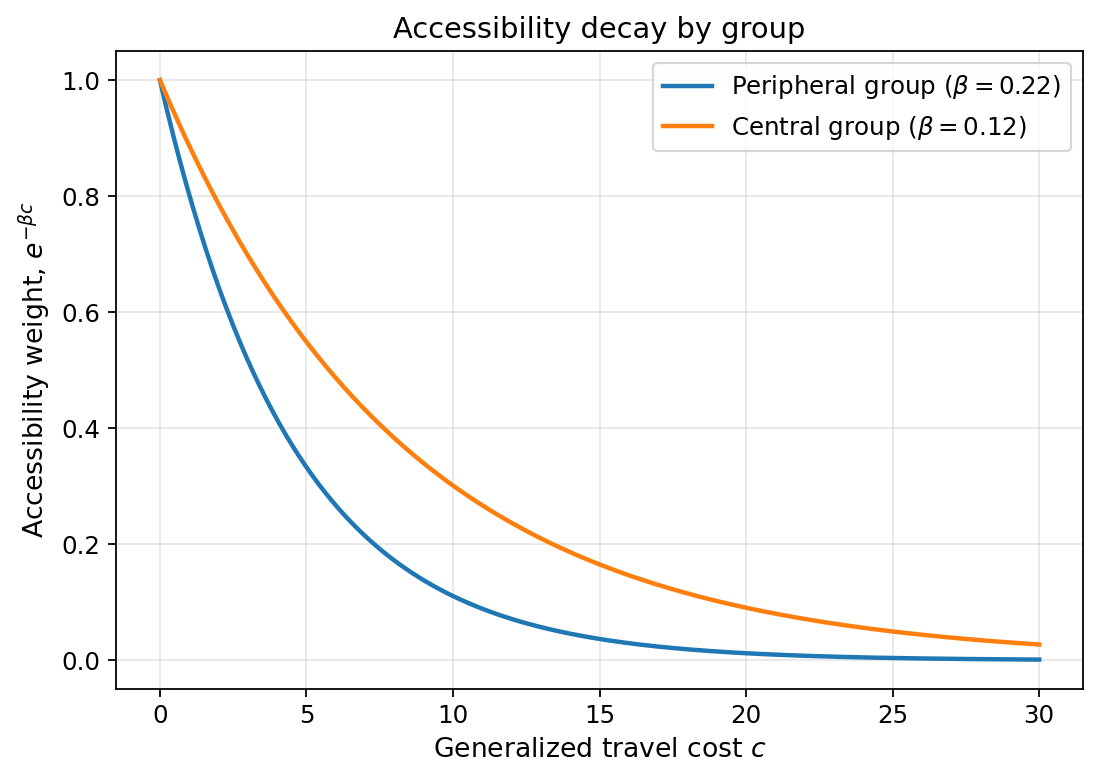

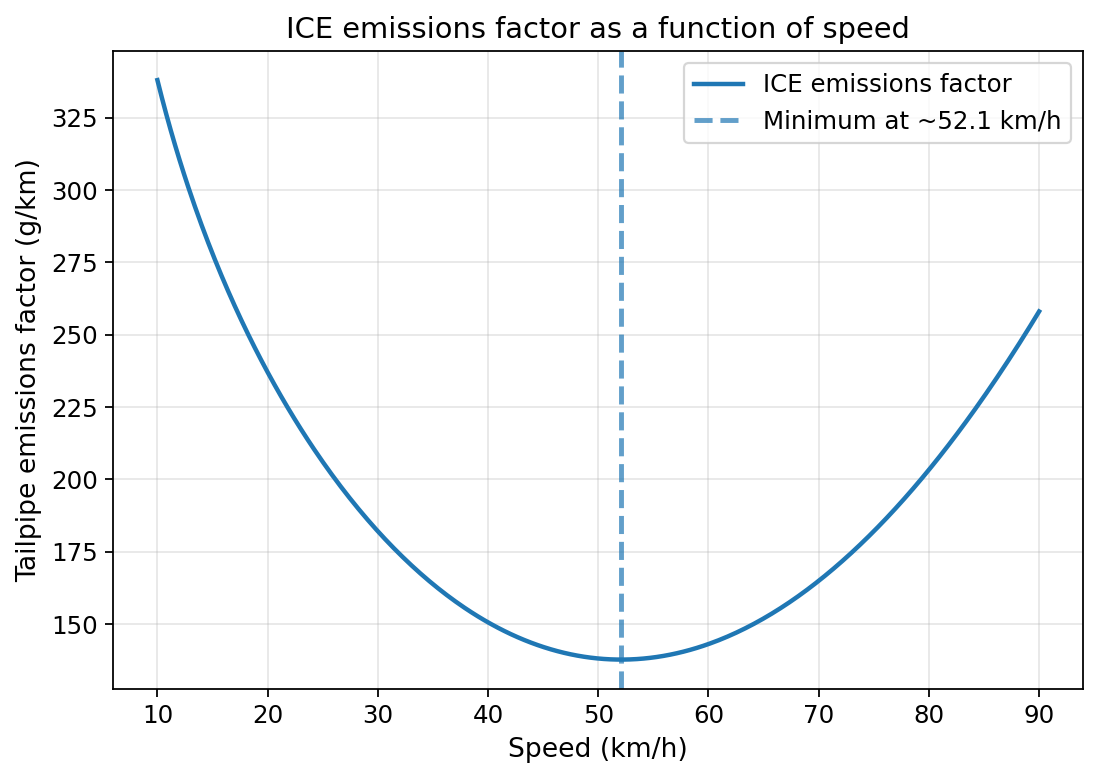

Minimum emissions factor occurs at about v = 52.11 km/h
Minimum ef_ice(v) = 137.63 g/km


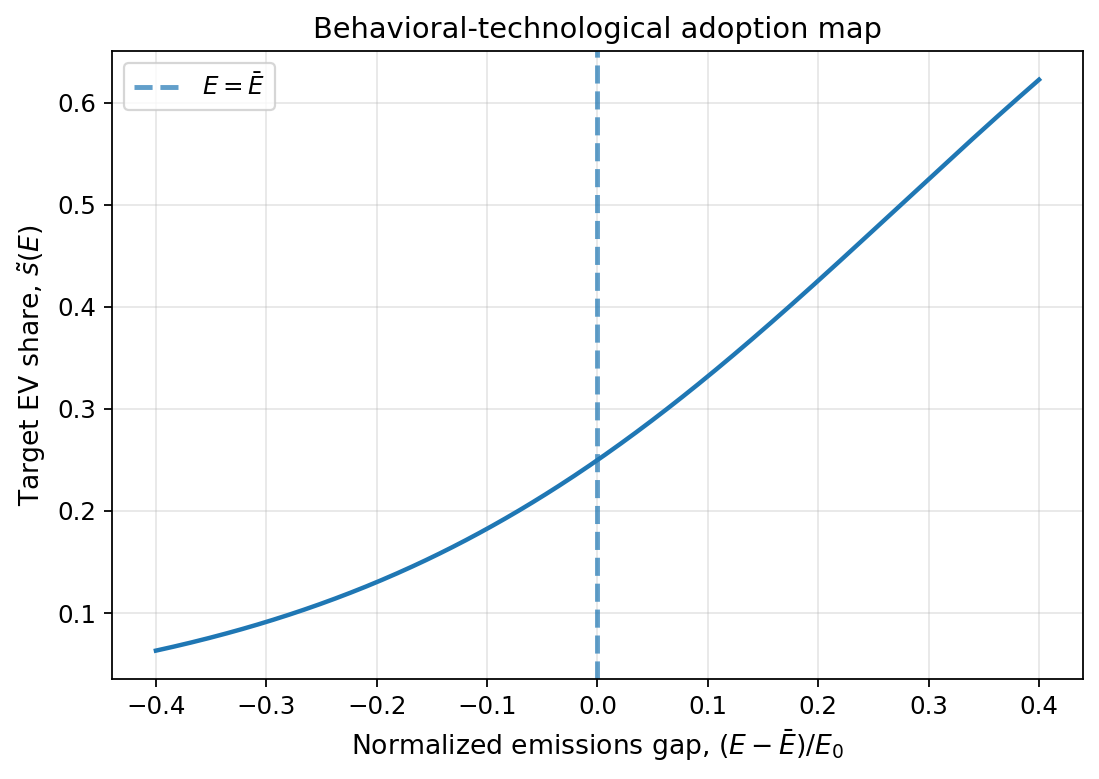

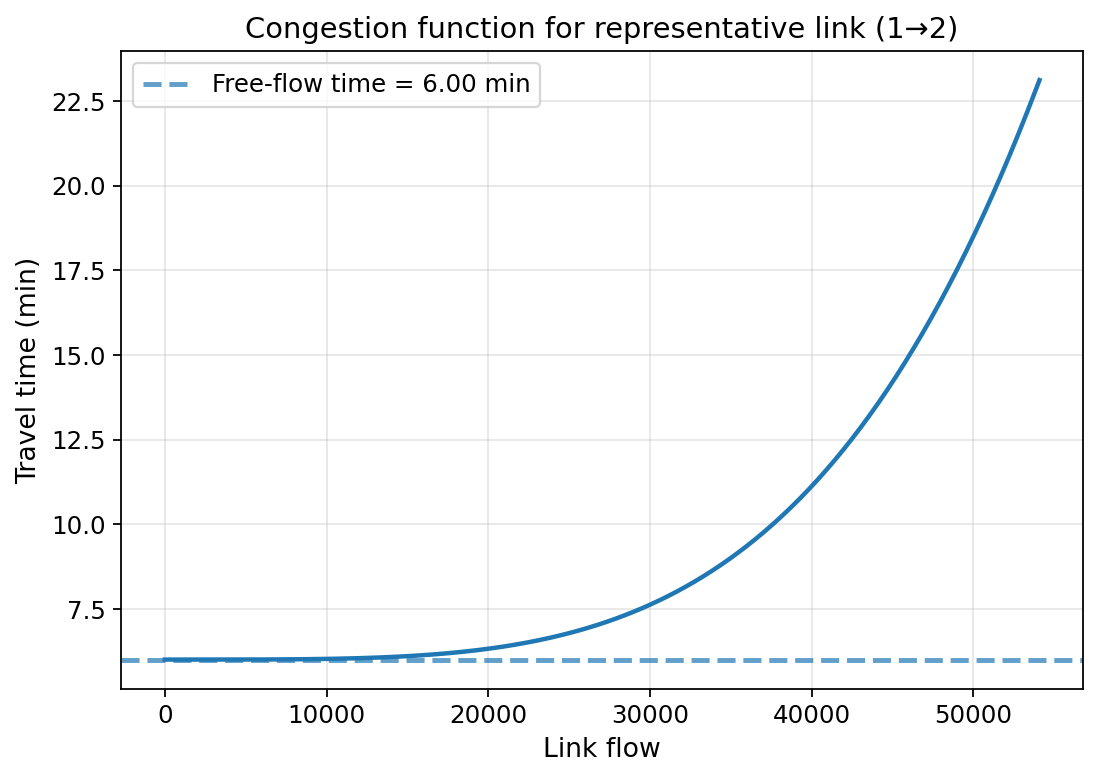

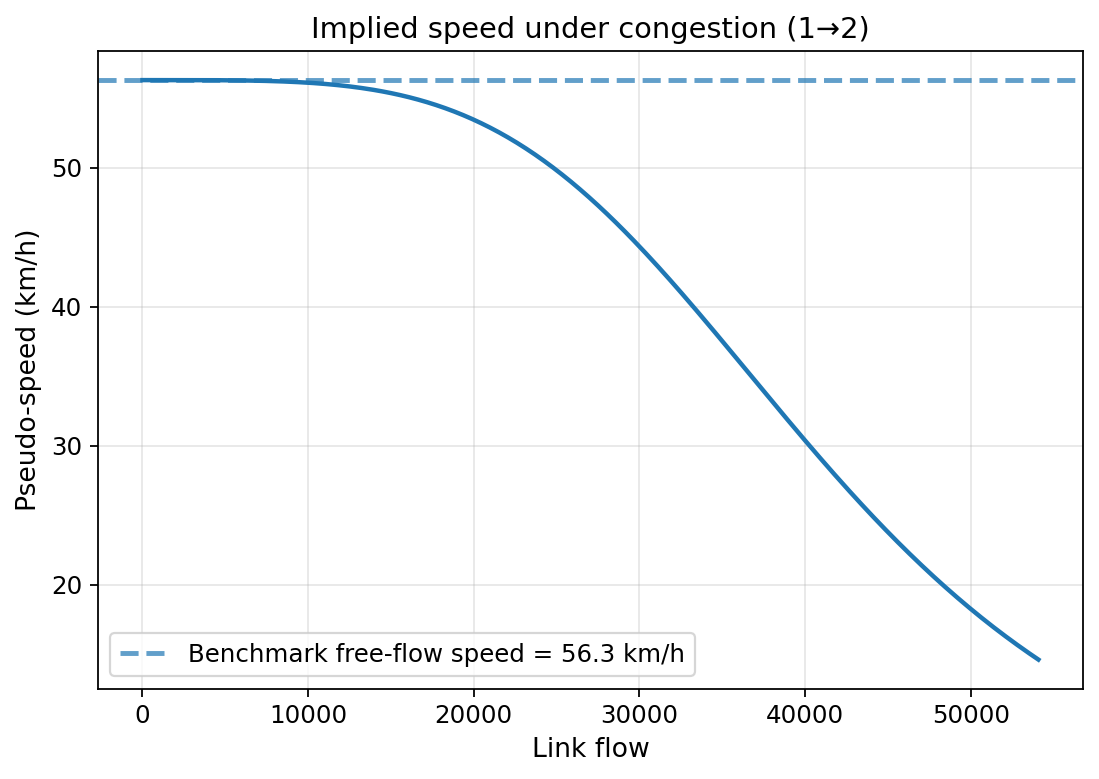

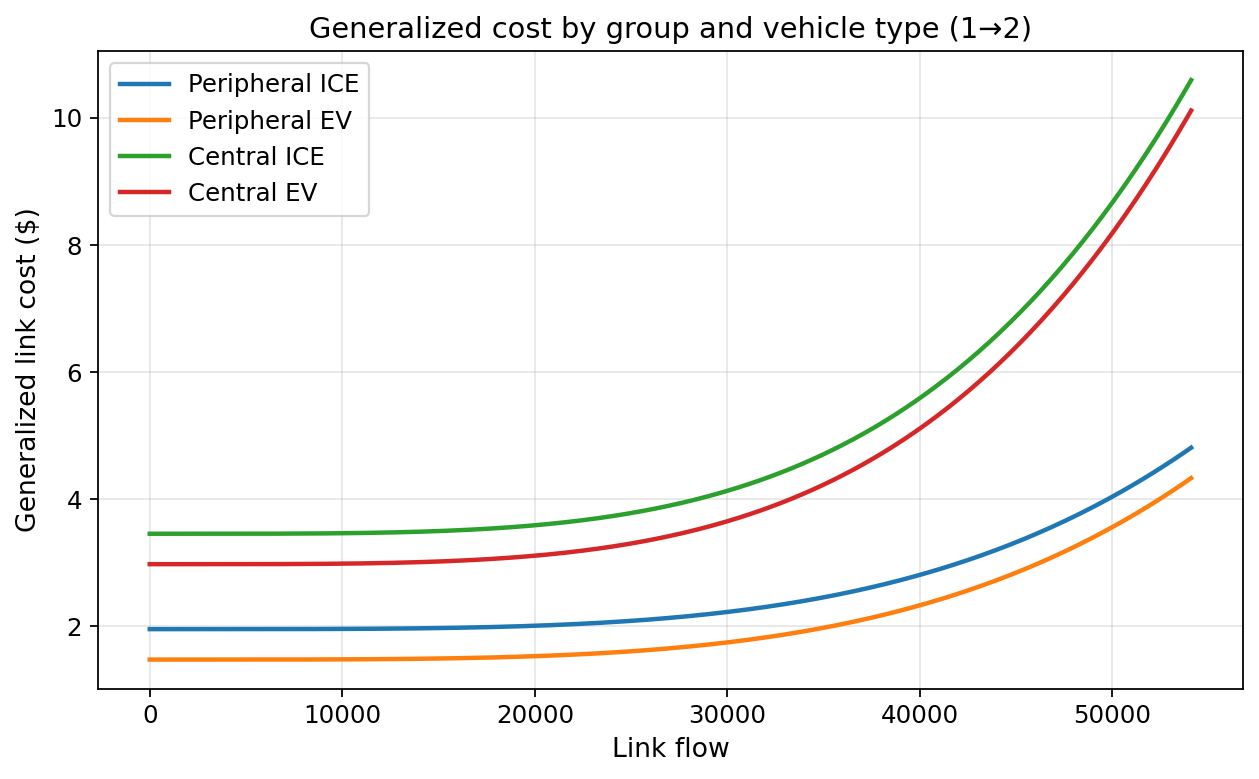

In [21]:
# ============================================================
# PAPER PLOTS: ASSUMED FUNCTIONS AND ACCESSIBILITY DECAY
# Run after Sections 6.1-6.5
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 160
plt.rcParams["font.size"] = 11

# ------------------------------------------------------------
# A. ACCESSIBILITY DECAY FOR THE TWO GROUPS
# ------------------------------------------------------------
# Exponential decay: exp(-beta * c), where c is generalized cost in $
c_grid = np.linspace(0, 30, 400)

decay_periph = np.exp(-BETA_PERIPH * c_grid)
decay_central = np.exp(-BETA_CENTRAL * c_grid)

plt.figure(figsize=(7, 5))
plt.plot(c_grid, decay_periph, linewidth=2, label=f"Peripheral group ($\\beta={BETA_PERIPH:.2f}$)")
plt.plot(c_grid, decay_central, linewidth=2, label=f"Central group ($\\beta={BETA_CENTRAL:.2f}$)")
plt.xlabel("Generalized travel cost $c$")
plt.ylabel("Accessibility weight, $e^{-\\beta c}$")
plt.title("Accessibility decay by group")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# B. EMISSIONS FACTOR VS SPEED (U-SHAPE)
# ------------------------------------------------------------
v_grid = np.linspace(10, 90, 400)
ef_grid = np.array([ef_ice(v) for v in v_grid])

v_star = v_grid[np.argmin(ef_grid)]
ef_star = ef_grid.min()

plt.figure(figsize=(7, 5))
plt.plot(v_grid, ef_grid, linewidth=2, label="ICE emissions factor")
plt.axvline(v_star, linestyle="--", alpha=0.7, label=f"Minimum at ~{v_star:.1f} km/h")
plt.xlabel("Speed (km/h)")
plt.ylabel("Tailpipe emissions factor (g/km)")
plt.title("ICE emissions factor as a function of speed")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Minimum emissions factor occurs at about v = {v_star:.2f} km/h")
print(f"Minimum ef_ice(v) = {ef_star:.2f} g/km")

# ------------------------------------------------------------
# C. SIGMOID EV ADOPTION MAP
# ------------------------------------------------------------
# target_s(E, E_BAR, E0) = sigmoid(G0 + GE * (E - E_BAR)/E0)
# Plot against normalized emissions gap z = (E - E_BAR)/E0
z_grid = np.linspace(-0.4, 0.4, 400)
s_target_grid = 1.0 / (1.0 + np.exp(-(G0 + GE * z_grid)))

plt.figure(figsize=(7, 5))
plt.plot(z_grid, s_target_grid, linewidth=2)
plt.axvline(0.0, linestyle="--", alpha=0.7, label=r"$E = \bar E$")
plt.xlabel(r"Normalized emissions gap, $(E-\bar E)/E_0$")
plt.ylabel(r"Target EV share, $\tilde{s}(E)$")
plt.title("Behavioral-technological adoption map")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# D. TRAVEL TIME VS FLOW FOR A REPRESENTATIVE LINK
# ------------------------------------------------------------
# Use the first link, or replace rep_idx with any specific index
rep_idx = 0
rep_row = links.iloc[rep_idx].copy()

# choose a flow range based on total OD scale
flow_max = max(2000, int(0.15 * od["demand"].sum()))
x_grid = np.linspace(0, flow_max, 300)
tt_grid = np.array([travel_time(x, rep_row) for x in x_grid])

plt.figure(figsize=(7, 5))
plt.plot(x_grid, tt_grid, linewidth=2)
plt.axhline(rep_row["a0"], linestyle="--", alpha=0.7, label=f"Free-flow time = {rep_row['a0']:.2f} min")
plt.xlabel("Link flow")
plt.ylabel("Travel time (min)")
plt.title(f"Congestion function for representative link ({int(rep_row['tail'])}→{int(rep_row['head'])})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# E. PSEUDO-SPEED VS FLOW FOR THE SAME REPRESENTATIVE LINK
# ------------------------------------------------------------
speed_grid = np.array([pseudo_speed(x, rep_row) for x in x_grid])

plt.figure(figsize=(7, 5))
plt.plot(x_grid, speed_grid, linewidth=2)
plt.axhline(VFF_KMH, linestyle="--", alpha=0.7, label=f"Benchmark free-flow speed = {VFF_KMH:.1f} km/h")
plt.xlabel("Link flow")
plt.ylabel("Pseudo-speed (km/h)")
plt.title(f"Implied speed under congestion ({int(rep_row['tail'])}→{int(rep_row['head'])})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# F. GENERALIZED COST VS FLOW BY GROUP AND VEHICLE TYPE
# ------------------------------------------------------------
c_p_ice = np.array([cost_periph_ice(x, rep_row) for x in x_grid])
c_p_ev  = np.array([cost_periph_ev(x, rep_row) for x in x_grid])
c_c_ice = np.array([cost_central_ice(x, rep_row) for x in x_grid])
c_c_ev  = np.array([cost_central_ev(x, rep_row) for x in x_grid])

plt.figure(figsize=(8, 5))
plt.plot(x_grid, c_p_ice, linewidth=2, label="Peripheral ICE")
plt.plot(x_grid, c_p_ev, linewidth=2, label="Peripheral EV")
plt.plot(x_grid, c_c_ice, linewidth=2, label="Central ICE")
plt.plot(x_grid, c_c_ev, linewidth=2, label="Central EV")
plt.xlabel("Link flow")
plt.ylabel("Generalized link cost ($)")
plt.title(f"Generalized cost by group and vehicle type ({int(rep_row['tail'])}→{int(rep_row['head'])})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()